In [1]:
# -*- coding: utf-8 -*-
"""
Created on December 22, 2022
Revised on April 01, 2025

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

SciKit-Learn Linear Regression Vignette
========================================

Description:
    Demonstrates simple and multiple linear regression using scikit-learn's
    LinearRegression estimator. Generates synthetic data with two independent
    variables (var1, var2) and one dependent variable (y), visualizes
    relationships with seaborn lmplot, then fits, predicts, and scores
    the model using the correct feature matrix X = df[["var1", "var2"]].
    Reports coefficients and intercept.

    Key sklearn API used:
        - LinearRegression.fit()
        - LinearRegression.predict()
        - LinearRegression.score()
        - LinearRegression.coef_
        - LinearRegression.intercept_

References:
    1. SciKit-Learn LinearRegression documentation
       https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Revision History:
    2022-12-22  Original development
                - Synthetic data generation with numpy linspace + normal noise
                - seaborn lmplot visualization
                - train_test_split, fit, predict, score demo

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Fixed: seaborn lmplot updated to data-first keyword order
                - Fixed: train_test_split now uses X = df[["var1", "var2"]]
                  to avoid data leakage (previously passed full df including target y)
"""


'\nCreated on December 22, 2022\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nSciKit-Learn Linear Regression Vignette\n========================================\n\nDescription:\n    Demonstrates simple and multiple linear regression using scikit-learn\'s\n    LinearRegression estimator. Generates synthetic data with two independent\n    variables (var1, var2) and one dependent variable (y), visualizes\n    relationships with seaborn lmplot, then fits, predicts, and scores\n    the model using the correct feature matrix X = df[["var1", "var2"]].\n    Reports coefficients and intercept.\n\n    Key sklearn API used:\n        - LinearRegression.fit()\n        - LinearRegression.predict()\n        - LinearRegression.score()\n        - LinearRegression.coef_\n    

# Linear Regresion

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sns.set_style("darkgrid")

# Create data

In [3]:
# Make variables have the same space 0 to 100 and generate 50 points

# Start with the dependent variable
y = np.linspace(0, 100, 50) + np.random.normal(scale=15, size=50)

# Now independent variables var1 and var2
var1 = np.linspace(0, 100, 50) + np.random.normal(scale=20, size=50)

var2 = np.linspace(0, 100, 50) + np.random.normal(scale=10, size=50)


# Build the DataFrame

In [4]:
df = pd.DataFrame({'y':y, 'var1':var1, 'var2':var2})

# Plot linear model

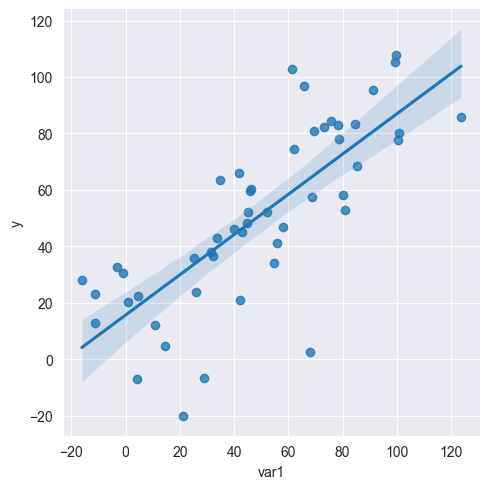

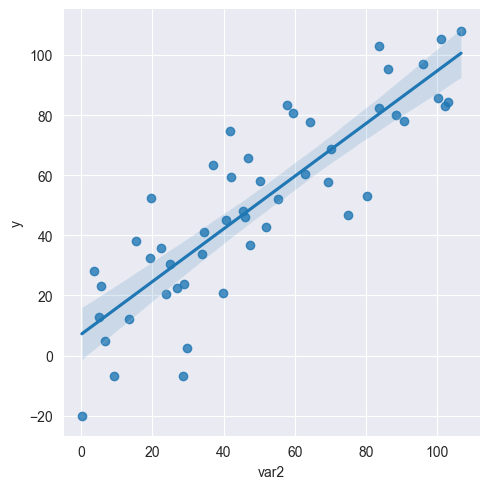

In [5]:
# seaborn lmplot: use data-first keyword order (best practice, seaborn >= 0.12)
sns.lmplot(data=df, x='var1', y='y')

sns.lmplot(data=df, x='var2', y='y')


# Linear Regression

## Create train, test datasets

In [6]:
# Feature matrix: use only independent variables (var1, var2) to avoid data leakage.
# Do NOT pass the full df which includes target y as a column.
X = df[['var1', 'var2']]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


In [7]:
y_test.shape

(10,)

## Fit the model

In [8]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predict

In [9]:
y_predict = model.predict(x_test)
y_predict

array([54.63450972, 51.39144819, 94.5801241 , 60.95356194, 85.36915338,
       10.67624091, 40.29993111, 11.14567594, 27.96841985, 14.90508815])

## Score

In [10]:
model.score(x_test, y_test)


0.8334543426962986

## Coefficients and Intercept

In [11]:
model.coef_

array([0.09815829, 0.76458452])

In [12]:
model.intercept_

np.float64(8.424170701402709)